In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import os

Successfully loaded history with 91 epochs.


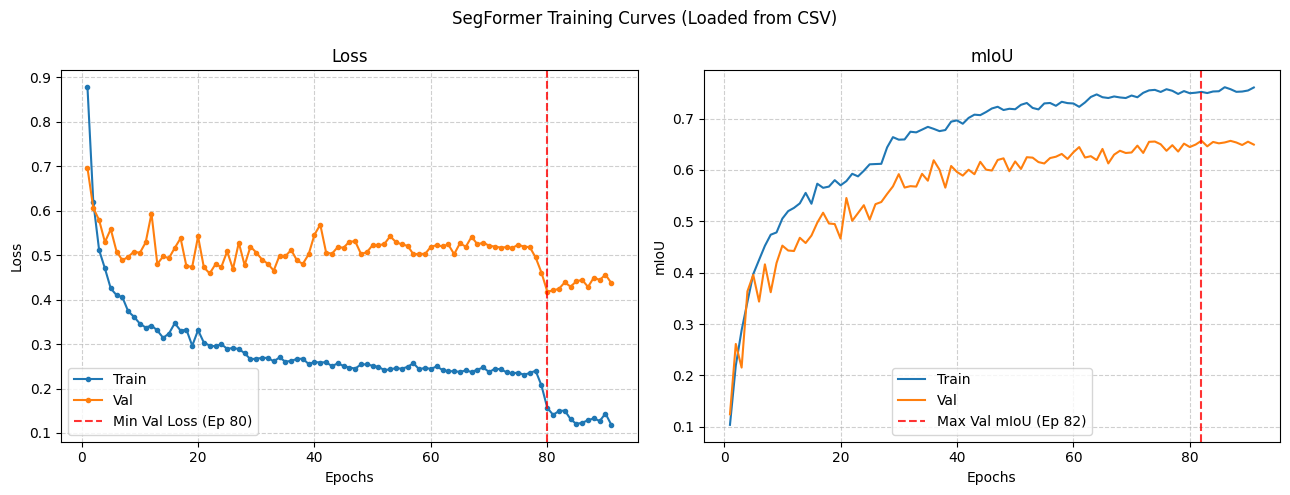

In [ ]:
history_csv_path = "training_history.csv"

if os.path.exists(history_csv_path):
    # 1. Load the data using pandas
    df = pd.read_csv(history_csv_path)
    print(f"Successfully loaded history with {len(df)} epochs.")

    # Find the optimal epochs
    best_loss_epoch = df.loc[df['val_loss'].idxmin(), 'epoch']
    best_miou_epoch = df.loc[df['val_miou'].idxmax(), 'epoch']

    # 2. Plotting Logic
    ep = df['epoch']
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5))

    # --- Loss Curve ---
    a1.plot(ep, df['train_loss'], label='Train', marker='o', markersize=3)
    a1.plot(ep, df['val_loss'], label='Val', marker='o', markersize=3)
    # Vertical line for lowest Val Loss
    a1.axvline(x=best_loss_epoch, color='red', linestyle='--', alpha=0.8, label=f'Min Val Loss (Ep {int(best_loss_epoch)})')

    a1.set_title('Loss')
    a1.set_xlabel('Epochs')
    a1.set_ylabel('Loss')
    a1.legend()
    a1.grid(True, linestyle='--', alpha=0.6)

    # --- mIoU Curve ---
    a2.plot(ep, df['train_miou'], label='Train', marker='o', markersize=3)
    a2.plot(ep, df['val_miou'], label='Val', marker='o', markersize=3)
    # Vertical line for highest Val mIoU
    a2.axvline(x=best_miou_epoch, color='red', linestyle='--', alpha=0.8, label=f'Max Val mIoU (Ep {int(best_miou_epoch)})')

    a2.set_title('mIoU')
    a2.set_xlabel('Epochs')
    a2.set_ylabel('mIoU')
    a2.legend()
    a2.grid(True, linestyle='--', alpha=0.6)

    plt.suptitle('SegFormer Training Curves (Loaded from CSV)')
    plt.tight_layout()

    # Save back to Drive
    # plot_path = os.path.join(os.path.dirname(history_csv_path), 'training_curves.png')
    # plt.savefig(plot_path, dpi=150)
    plt.show()
    # print(f"Plot updated and saved to: {plot_path}")

else:
    print(f"Error: Could not find history file at {history_csv_path}. Run the training loop first!")